# Part 1

## Learn a FVSBN model for CIFAR-10 and then generate 20 images randomly.

In [20]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

device = "cpu"

### Set output folder and hyperparameters

In [21]:
data_dir = "./data"
out_dir = "./outputs_fvsbn"
os.makedirs(out_dir, exist_ok=True)

epochs = 10
batch_size = 128
lr = 0.0001
num_workers = 2

torch.manual_seed(123)

D = 3 * 32 * 32  # CIFAR-10 flattened size

Load Dataset

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),   # converts to [0,1] float tensor, shape [3,32,32]
])

train_set = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

len(train_set), len(test_set)


(50000, 10000)

Convert CIFAR pixels to binary

In [23]:
# Cell 3 — Dynamic (stochastic) binarization
def stochastic_binarize(x: torch.Tensor) -> torch.Tensor:
    return torch.bernoulli(x.clamp(0.0, 1.0))



## Define Model

In [24]:
class FVSBN(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.input_size = input_size

        self.W = nn.Parameter(torch.randn(input_size, input_size) * 0.01)
        self.bias = nn.Parameter(torch.zeros(input_size))

        mask = torch.tril(torch.ones(input_size, input_size), diagonal=-1)  # strictly lower
        self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, D]
        masked_W = self.W * self.mask
        logits = x @ masked_W.t() + self.bias  # tranpsose
        return logits

    @torch.no_grad()
    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        # ancestral sampling: x0 -> x1 -> ... -> x_{D-1}
        self.eval()
        D = self.input_size
        samples = torch.zeros(n, D, device=device)

        W = (self.W * self.mask).to(device)
        b = self.bias.to(device)

        for j in range(D):
            if j == 0:
                logits_j = b[j].expand(n)
            else:
                logits_j = b[j] + (samples[:, :j] * W[j, :j]).sum(dim=1)

            p = torch.sigmoid(logits_j)
            samples[:, j] = torch.bernoulli(p)

        return samples


## Train

In [25]:
model = FVSBN(D).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    total_count = 0

    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)     # [B,3,32,32], in [0,1]
        x = images.view(images.size(0), D)                # [B,D]
        x_bin = stochastic_binarize(x)                    # [B,D] in {0,1}

        logits = model(x_bin)                             # [B,D]
        loss = F.binary_cross_entropy_with_logits(logits, x_bin, reduction="mean")

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    print(f"Epoch {epoch:02d} | Train BCE: {total_loss / total_count:.4f}")


Epoch 01 | Train BCE: 0.6582
Epoch 02 | Train BCE: 0.6378
Epoch 03 | Train BCE: 0.6307
Epoch 04 | Train BCE: 0.6265
Epoch 05 | Train BCE: 0.6235
Epoch 06 | Train BCE: 0.6213
Epoch 07 | Train BCE: 0.6195
Epoch 08 | Train BCE: 0.6180
Epoch 09 | Train BCE: 0.6167
Epoch 10 | Train BCE: 0.6155


## Generate Images

In [26]:
with torch.no_grad():
    samples = model.sample(20, device=device)          # [20,D] binary
    samples_img = samples.view(20, 3, 32, 32).cpu()    # [20,3,32,32]

grid = make_grid(samples_img, nrow=5)
out_path = os.path.join(out_dir, "generated_20.png")
save_image(grid, out_path)
out_path


'./outputs_fvsbn/generated_20.png'

## Show Images

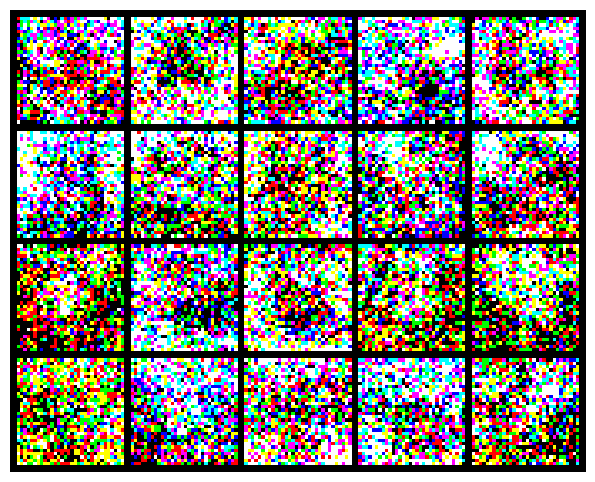

In [27]:
import matplotlib.pyplot as plt
import numpy as np

img = torchvision.io.read_image(out_path).permute(1, 2, 0).numpy()
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# Train a variational auto-encoder with dimension 30 for mean and variance on CIFAR-10.

Set up DataLoaders and Hyperparameters

In [28]:
data_dir = "./data"
out_dir = "./outputs_vae"
os.makedirs(out_dir, exist_ok=True)

batch_size = 128
epochs = 30
lr = 1e-3
num_workers = 2
torch.manual_seed(123)

transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


## Set up CVAE Model

In [29]:
LATENT_DIM = 30
N_CLASSES = 10
LABEL_EMB = 32  # small embedding size for labels

class CVAE(nn.Module):
    def __init__(self, latent_dim=30, n_classes=10, label_emb_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes = n_classes

        self.label_emb = nn.Embedding(n_classes, label_emb_dim)

        # Encoder: 3x32x32 -> features
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 64x16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 128x8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 256x4x4
            nn.ReLU(),
        )
        self.enc_flat = 256 * 4 * 4

        # mu/logvar depend on (features + label embedding)
        self.fc_mu = nn.Linear(self.enc_flat + label_emb_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat + label_emb_dim, latent_dim)

        # Decoder: (z + label embedding) -> 3x32x32
        self.fc_dec = nn.Linear(latent_dim + label_emb_dim, self.enc_flat)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 128x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 64x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 3x32x32
            nn.Sigmoid(),  # output in [0,1]
        )

    def encode(self, x, y):
        h = self.enc(x).view(x.size(0), -1)        # [B, enc_flat]
        y_emb = self.label_emb(y)                  # [B, label_emb_dim]
        h_cat = torch.cat([h, y_emb], dim=1)       # [B, enc_flat+emb]
        mu = self.fc_mu(h_cat)                     # [B, latent_dim]
        logvar = self.fc_logvar(h_cat)             # [B, latent_dim]
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)                  # [B, label_emb_dim]
        z_cat = torch.cat([z, y_emb], dim=1)       # [B, latent_dim+emb]
        h = self.fc_dec(z_cat).view(z.size(0), 256, 4, 4)
        return self.dec(h)                         # [B,3,32,32]

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, y)
        return recon, mu, logvar


Define Loss

In [30]:
def vae_loss(recon, x, mu, logvar):
    # recon loss: BCE works fine since output is sigmoid in [0,1]
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    # KL divergence to N(0,1)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl, recon_loss, kl


## Train

In [31]:
model = CVAE(latent_dim=LATENT_DIM, n_classes=N_CLASSES, label_emb_dim=LABEL_EMB).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(1, epochs + 1):
    model.train()
    total, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        recon, mu, logvar = model(x, y)
        loss, rloss, kl = vae_loss(recon, x, mu, logvar)

        opt.zero_grad()
        loss.backward()
        opt.step()

        bs = x.size(0)
        total += loss.item() * bs
        total_recon += rloss.item() * bs
        total_kl += kl.item() * bs
        n += bs

    print(f"Epoch {epoch:02d} | Loss {total/n:.3f} | Recon {total_recon/n:.3f} | KL {total_kl/n:.3f}")


Epoch 01 | Loss 1897.134 | Recon 1874.961 | KL 22.173
Epoch 02 | Loss 1835.962 | Recon 1804.570 | KL 31.392
Epoch 03 | Loss 1828.709 | Recon 1795.052 | KL 33.657
Epoch 04 | Loss 1826.043 | Recon 1791.726 | KL 34.317
Epoch 05 | Loss 1824.429 | Recon 1789.874 | KL 34.555
Epoch 06 | Loss 1823.184 | Recon 1788.352 | KL 34.833
Epoch 07 | Loss 1822.756 | Recon 1787.854 | KL 34.902
Epoch 08 | Loss 1822.260 | Recon 1787.363 | KL 34.897
Epoch 09 | Loss 1821.674 | Recon 1786.723 | KL 34.951
Epoch 10 | Loss 1821.418 | Recon 1786.478 | KL 34.940
Epoch 11 | Loss 1820.982 | Recon 1786.036 | KL 34.946
Epoch 12 | Loss 1820.568 | Recon 1785.568 | KL 35.000
Epoch 13 | Loss 1820.319 | Recon 1785.322 | KL 34.997
Epoch 14 | Loss 1820.107 | Recon 1785.053 | KL 35.054
Epoch 15 | Loss 1819.818 | Recon 1784.804 | KL 35.014
Epoch 16 | Loss 1819.591 | Recon 1784.572 | KL 35.019
Epoch 17 | Loss 1819.341 | Recon 1784.198 | KL 35.143
Epoch 18 | Loss 1819.104 | Recon 1784.006 | KL 35.098
Epoch 19 | Loss 1818.941 | R

## 10 Labeled Images

In [32]:
@torch.no_grad()
def generate_per_class(model, n_per_class=10):
    model.eval()
    all_imgs = []
    all_labels = []

    for c in range(N_CLASSES):
        y = torch.full((n_per_class,), c, device=device, dtype=torch.long)
        z = torch.randn(n_per_class, LATENT_DIM, device=device)
        imgs = model.decode(z, y).cpu()
        all_imgs.append(imgs)
        all_labels.extend([c] * n_per_class)

    all_imgs = torch.cat(all_imgs, dim=0)  # [100,3,32,32]
    return all_imgs, all_labels

imgs100, labels100 = generate_per_class(model, n_per_class=10)

grid = make_grid(imgs100, nrow=10)  # each row is one class (10 images)
path = os.path.join(out_dir, "gen_10_per_class.png")
save_image(grid, path)
path

for c in range(10):
    print(f"Row {c}: {class_names[c]}")



Row 0: airplane
Row 1: automobile
Row 2: bird
Row 3: cat
Row 4: deer
Row 5: dog
Row 6: frog
Row 7: horse
Row 8: ship
Row 9: truck


## Generate "In-Between" Images

In [34]:
import random


@torch.no_grad()
def decode_with_mixed_label(model, z, ya, yb, t=0.5):
    # interpolate between label embeddings
    ea = model.label_emb(ya)
    eb = model.label_emb(yb)
    e = (1 - t) * ea + t * eb  # [B, emb]

    z_cat = torch.cat([z, e], dim=1)
    h = model.fc_dec(z_cat).view(z.size(0), 256, 4, 4)
    return model.dec(h)  # [B,3,32,32]

@torch.no_grad()
def generate_in_between_pairs(model, n=10, t=0.5):
    model.eval()
    imgs = []
    pairs = []

    for _ in range(n):
        a, b = random.sample(range(10), 2)
        ya = torch.tensor([a], device=device)
        yb = torch.tensor([b], device=device)

        za = torch.randn(1, LATENT_DIM, device=device)
        zb = torch.randn(1, LATENT_DIM, device=device)
        z = (1 - t) * za + t * zb

        img = decode_with_mixed_label(model, z, ya, yb, t=t).cpu()
        imgs.append(img)
        pairs.append((a, b))

    return torch.cat(imgs, dim=0), pairs

between_imgs, between_pairs = generate_in_between_pairs(model, n=10, t=0.5)

grid = make_grid(between_imgs, nrow=5)
path = os.path.join(out_dir, "gen_10_in_between.png")
save_image(grid, path)
path


for i, (a, b) in enumerate(between_pairs):
    print(f"Image {i}: between {class_names[a]} ↔ {class_names[b]}")


Image 0: between frog ↔ deer
Image 1: between airplane ↔ bird
Image 2: between automobile ↔ dog
Image 3: between ship ↔ cat
Image 4: between bird ↔ dog
Image 5: between cat ↔ automobile
Image 6: between horse ↔ frog
Image 7: between cat ↔ frog
Image 8: between ship ↔ horse
Image 9: between dog ↔ deer


# Visualize Images and In-Between Images

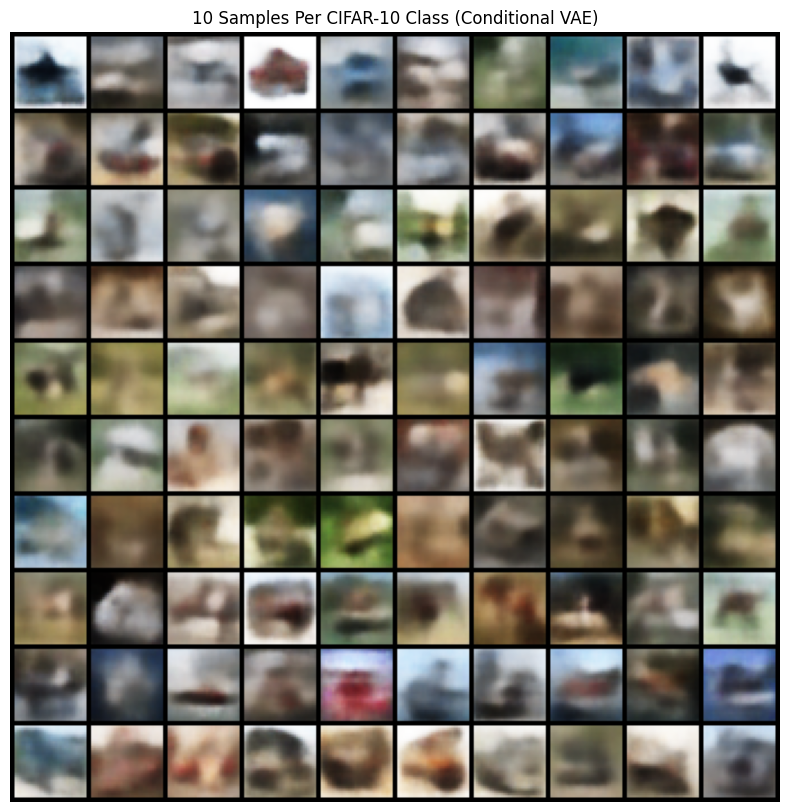

Row 0: airplane
Row 1: automobile
Row 2: bird
Row 3: cat
Row 4: deer
Row 5: dog
Row 6: frog
Row 7: horse
Row 8: ship
Row 9: truck


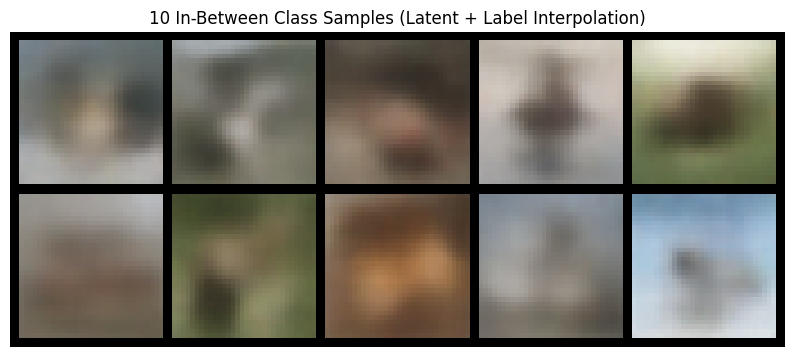

Image 0: between frog ↔ deer
Image 1: between airplane ↔ bird
Image 2: between automobile ↔ dog
Image 3: between ship ↔ cat
Image 4: between bird ↔ dog
Image 5: between cat ↔ automobile
Image 6: between horse ↔ frog
Image 7: between cat ↔ frog
Image 8: between ship ↔ horse
Image 9: between dog ↔ deer


In [35]:
# Load and show the saved grid image
img = torchvision.io.read_image("./outputs_vae/gen_10_per_class.png")
img = img.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("10 Samples Per CIFAR-10 Class (Conditional VAE)")
plt.show()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

for i, name in enumerate(class_names):
    print(f"Row {i}: {name}")


img2 = torchvision.io.read_image("./outputs_vae/gen_10_in_between.png")
img2 = img2.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 6))
plt.imshow(img2)
plt.axis("off")
plt.title("10 In-Between Class Samples (Latent + Label Interpolation)")
plt.show()

for i, (a, b) in enumerate(between_pairs):
    print(f"Image {i}: between {class_names[a]} ↔ {class_names[b]}")
